# Universidad de los Andes

## Aprendizaje por refuerzo profundo

### Reto 1 - Assaul

### Grupo 6

**LEIDY DAYANA VEGA MEDINA**

**JERSSON MAURICIO RODRIGUEZ APONTE**

2026

## 1. Bootstrap Local -> GitHub -> Colab

**Descripci?n de la celda de c?digo**

Esta celda prepara el contexto inicial de ejecuci?n del notebook antes de importar la l?gica principal del proyecto. Define variables de entorno con valores por defecto para seleccionar la rama o referencia de Git que se usar?, el perfil de entrenamiento full, el identificador l?gico del experimento, el modo autom?tico de ejecuci?n, los par?metros de evaluaci?n final y el l?mite de pasos del video. Tambi?n elimina cualquier commit fijo previo para favorecer la resoluci?n din?mica de la referencia indicada. Despu?s detecta si el notebook est? corriendo en Google Colab intentando importar `google.colab.drive`. Si Colab est? disponible, monta Google Drive y define `BASE` como la carpeta persistente del proyecto dentro de `MyDrive`; si no, usa el directorio actual como base local. Finalmente configura rutas persistentes para MLflow, checkpoints y TensorBoard, dejando que valores definidos previamente por el usuario tengan prioridad. En resumen, esta celda establece la capa de configuraci?n externa y almacenamiento compartido que permite ejecutar el mismo notebook en local o en Colab.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("ASSAULT_BOOTSTRAP_REF", "feature/hu011-entregable-final-assault")
os.environ.pop("ASSAULT_BOOTSTRAP_COMMIT", None)
os.environ.setdefault("ASSAULT_TRAINING_PROFILE", "full")
os.environ.setdefault("ASSAULT_PROJECT_RUN_ID", "assault_ddqn_full_001")
os.environ.setdefault("ASSAULT_REQUESTED_MODE", "auto")
os.environ.setdefault("ASSAULT_EXECUTION_MODE", "auto")
os.environ.setdefault("ASSAULT_EVALUATION_EPISODES", "10")
os.environ.setdefault("ASSAULT_EVALUATION_EPSILON", "0.0")
os.environ.setdefault("ASSAULT_VIDEO_MAX_STEPS", "1800")
os.environ.setdefault("GLOBAL_RETO_MULTI_ALGORITHM", "PENDING")

try:
    from google.colab import drive  # type: ignore
except ImportError:
    drive = None

if drive is not None:
    drive.mount("/content/drive")
    BASE = Path("/content/drive/MyDrive/reinforcement_learning_reto_1")
else:
    BASE = Path.cwd()

os.environ.setdefault("ASSAULT_MLFLOW_TRACKING_URI", (BASE / "mlruns").as_uri())
os.environ.setdefault("ASSAULT_CHECKPOINT_DIR", str(BASE / "checkpoints"))
os.environ.setdefault("ASSAULT_TENSORBOARD_DIR", str(BASE / "tensorboard"))
print("BASE:", BASE)

Mounted at /content/drive
BASE: /content/drive/MyDrive/reinforcement_learning_reto_1


**Descripci?n de la celda de c?digo**

Esta celda realiza el bootstrap reproducible del repositorio y de las dependencias necesarias para ejecutar el notebook desde una fuente de verdad versionada. Primero define la URL del repositorio, la ruta esperada en Colab, la referencia o commit solicitado y si deben instalarse dependencias. Luego declara dos funciones auxiliares: una para detectar Colab y otra para ejecutar comandos Git que devuelven texto. En Colab, clona el repositorio si a?n no existe, actualiza referencias remotas, resuelve el SHA de la rama o commit solicitado y hace checkout detached para evitar ejecutar c?digo ambiguo. En local, identifica la ra?z real del repositorio mediante Git. Despu?s ajusta `sys.path` para que los imports usen la copia correcta de `2_Assault`, importa utilidades de bootstrap del proyecto, prepara el entorno, instala `requirements.txt` si corresponde y verifica que `src.environment` provenga del checkout esperado. La salida imprime el SHA ejecutado y el archivo importado, dejando evidencia de reproducibilidad y evitando depender de c?digo viejo en memoria.

In [2]:
import subprocess
import sys

REPO_URL = "https://github.com/j-mauro-r/reinforcement_learning_reto_1.git"
COLAB_ROOT = Path("/content/reinforcement_learning_reto_1")
BOOTSTRAP_REF = os.environ.get("ASSAULT_BOOTSTRAP_REF", "main")
BOOTSTRAP_COMMIT = os.environ.get("ASSAULT_BOOTSTRAP_COMMIT") or None
INSTALL_DEPENDENCIES = os.environ.get("ASSAULT_INSTALL_DEPENDENCIES", "1") == "1"

def _running_in_colab():
    try:
        import google.colab  # type: ignore  # noqa: F401
    except ImportError:
        return False
    return True

def _git_output(args, cwd):
    return subprocess.check_output(["git", *args], cwd=str(cwd), text=True).strip()

if _running_in_colab():
    if not (COLAB_ROOT / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(COLAB_ROOT)], check=True)
    subprocess.run(["git", "fetch", "--prune", "origin"], cwd=str(COLAB_ROOT), check=True)
    provisional_ref = BOOTSTRAP_COMMIT or f"origin/{BOOTSTRAP_REF}"
    provisional_sha = _git_output(["rev-parse", "--verify", f"{provisional_ref}^{{commit}}"], COLAB_ROOT)
    subprocess.run(["git", "checkout", "--detach", provisional_sha], cwd=str(COLAB_ROOT), check=True)
    ASSAULT_DIR = COLAB_ROOT / "2_Assault"
else:
    PROJECT_ROOT = Path(_git_output(["rev-parse", "--show-toplevel"], Path.cwd()))
    ASSAULT_DIR = PROJECT_ROOT / "2_Assault"

for path in (ASSAULT_DIR, ASSAULT_DIR.parent):
    value = str(path.resolve())
    if value in sys.path:
        sys.path.remove(value)
    sys.path.insert(0, value)

from src.execution_bootstrap import install_project_requirements, prepare_execution_environment, verify_environment_import

bootstrap = prepare_execution_environment(
    requested_ref=BOOTSTRAP_REF,
    requested_commit=BOOTSTRAP_COMMIT,
    repo_url=REPO_URL,
    colab_root=COLAB_ROOT,
)
PROJECT_ROOT = bootstrap.repo_root
ASSAULT_DIR = bootstrap.assault_dir
if INSTALL_DEPENDENCIES:
    install_project_requirements(bootstrap.requirements_path)
environment_source = verify_environment_import(bootstrap)
print("EXECUTED_SHA:", bootstrap.resolved_sha)
print("src.environment:", environment_source)

Execution bootstrap
  runtime: Google Colab
  repository: /content/reinforcement_learning_reto_1
  assault_dir: /content/reinforcement_learning_reto_1/2_Assault
  requested_ref: feature/hu011-entregable-final-assault
  requested_commit: <none>
  resolved_sha: f0a6609be173ba19eb6fe4e41fd61e4524cfd606
  requirements: /content/reinforcement_learning_reto_1/2_Assault/requirements.txt
src.environment import source: /content/reinforcement_learning_reto_1/2_Assault/src/environment.py
EXECUTED_SHA: f0a6609be173ba19eb6fe4e41fd61e4524cfd606
src.environment: /content/reinforcement_learning_reto_1/2_Assault/src/environment.py


## 2. Imports, configuración y fuentes de evidencia

**Descripci?n de la celda de c?digo**

Esta celda concentra los imports funcionales del flujo Assault y carga las configuraciones y evidencias base que se usar?n en el resto del notebook. Importa utilidades est?ndar como `json`, `math`, `torch` y funciones de visualizaci?n de IPython, y despu?s trae desde `src` los m?dulos responsables del agente DDQN, creaci?n del entorno, evaluaci?n, resoluci?n de modos HU009C, entrega HU011, exportaci?n del modelo compacto, preflight, generaci?n de figuras TensorBoard, bootstrap de sesiones, perfiles de entrenamiento, sesi?n de entrenamiento y video. Con esos componentes ya disponibles, lee el YAML central de configuraci?n, resuelve el perfil solicitado mediante `resolve_training_profile`, obtiene la configuraci?n efectiva, recupera la seed reproducible y captura informaci?n del runtime actual. Tambi?n carga el baseline aleatorio y el resumen hist?rico de entrenamiento full desde archivos de datos versionados, que sirven como evidencia cuando el notebook est? en modo delivery y no reentrena. Al final imprime el perfil activo, el runtime y el baseline para que la ejecuci?n quede auditada desde el inicio de la fase anal?tica.

In [3]:
import json
import math
import torch
from IPython.display import Markdown, Video, display

from src.agent import DDQNAgent
from src.environment import create_assault_env, get_environment_metadata, validate_frameskip_once
from src.evaluator import evaluate_agent
from src.hu009c_delivery import resolve_hu009c_execution_mode
from src.hu011_delivery import (
    MANDATORY_ASSAULT_CRITERIA, build_delivery_gate, build_evaluation_artifact,
    compare_with_random_baseline, criteria_from_statuses, load_random_baseline,
    plot_exploitation_rewards, validate_exploitation_figure_data, write_json_atomic,
)
from src.model_artifact import export_inference_model, load_inference_model
from src.preflight import run_preflight_checks
from src.reporting import plot_training_figures, prepare_training_figures
from src.session_bootstrap import compute_config_fingerprint, prepare_training_session, update_experiment_state_after_success
from src.training_profiles import resolve_training_profile
from src.training_session import run_training_session
from src.utils import get_runtime_info, load_yaml_config
from src.video import generate_assault_demo_video

BASE_CONFIG = load_yaml_config(ASSAULT_DIR / "configs" / "ddqn_config.yaml")
profile_context = resolve_training_profile(BASE_CONFIG, os.environ.get("ASSAULT_TRAINING_PROFILE", "full"))
config = profile_context.config
seed = int(config["reproducibility"]["seed"])
runtime_info = get_runtime_info()
random_baseline = load_random_baseline(ASSAULT_DIR / "data" / "baseline_random_assault.json")
full_training_evidence = json.loads((ASSAULT_DIR / "data" / "full_training_summary_assault.json").read_text(encoding="utf-8"))
print("TRAINING_PROFILE=", profile_context.name)
print("RUNTIME=", runtime_info)
print("RANDOM_BASELINE=", random_baseline.as_dict())

TRAINING_PROFILE= full
RUNTIME= {'python_version': '3.13.15', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.35', 'gymnasium_version': '1.1.1', 'ale_py_version': '0.10.1', 'cpu': 'x86_64', 'cpu_count_logical': 12, 'cpu_count_physical': 6, 'ram_total_gb': 83.47, 'ram_available_gb': 81.27, 'gpu_available': True, 'gpu_name': 'NVIDIA A100-SXM4-40GB', 'gpu_vram_total_gb': 39.49, 'cuda_version': '12.8', 'torch_version': '2.11.0+cu128'}
RANDOM_BASELINE= {'source': '2_Assault/experimento_0_assault.ipynb', 'episodes': 10, 'seeds': [42, 43, 44, 45, 46, 47, 48, 49, 50, 51], 'rewards': [189.0, 273.0, 273.0, 210.0, 210.0, 399.0, 315.0, 189.0, 189.0, 378.0], 'episode_lengths': [577, 670, 694, 454, 480, 766, 640, 385, 622, 662], 'mean_reward': 262.5, 'median_reward': 241.5, 'std_reward': 75.27848298152666, 'min_reward': 189.0, 'max_reward': 399.0}


## 3. Entorno, preprocessing y preflight

**Descripci?n de la celda de c?digo**

Esta celda valida que el pipeline de entorno y entrenamiento b?sico siga siendo consistente antes de permitir cualquier operaci?n costosa o dependiente de artefactos. Crea un entorno de entrenamiento y otro de evaluaci?n con seeds distintas para confirmar que ambos modos pueden construirse desde la misma configuraci?n efectiva. Reinicia el entorno de entrenamiento, obtiene metadatos operativos y verifica condiciones contractuales del proyecto: observaciones con shape `(4, 84, 84)`, tipo `uint8`, espacio de acciones discreto con siete acciones y frameskip efectivo igual a cuatro. Despu?s cierra expl?citamente ambos entornos para no dejar recursos abiertos. A continuaci?n ejecuta `run_preflight_checks`, que prueba componentes como red, agente, Replay Buffer y actualizaci?n DDQN en una corrida corta y barata. Si el preflight no est? listo para entrenamiento, la celda falla con un resumen diagn?stico; si todo est? correcto, imprime `READY_FOR_TRAINING=True` y los metadatos del entorno. Su funci?n es actuar como puerta t?cnica temprana, detectando incompatibilidades de entorno o configuraci?n antes de entrenar, reanudar o generar artefactos.

In [4]:
train_env = create_assault_env(config, mode="train", seed=seed)
eval_probe = create_assault_env(config, mode="eval", seed=seed + 1)
obs, info = train_env.reset(seed=seed)
env_metadata = get_environment_metadata(train_env, config, mode="train", seed=seed)
assert obs.shape == (4, 84, 84)
assert str(obs.dtype) == "uint8"
assert train_env.action_space.n == 7
assert validate_frameskip_once(train_env, expected_frameskip=4, steps=5)
train_env.close()
eval_probe.close()
preflight_report = run_preflight_checks(config)
if not preflight_report.ready_for_training:
    raise RuntimeError(preflight_report.format_summary())
print("READY_FOR_TRAINING=True")
print(env_metadata)

READY_FOR_TRAINING=True
EnvironmentMetadata(env_id='ALE/Assault-v5', mode='train', seed=42, action_space='Discrete(7)', action_meanings=('NOOP', 'FIRE', 'UP', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE'), observation_shape=(4, 84, 84), observation_dtype='uint8', base_frameskip=4, wrapper_frameskip=1, effective_frameskip=4, repeat_action_probability=0.25, full_action_space=False)


## 4. Ejecución automática: NEW / RESUME / DELIVERY

**Descripci?n de la celda de c?digo**

Esta celda decide qu? camino debe seguir el notebook para el experimento Assault actual: entrenamiento nuevo, reanudaci?n o entrega directa. Primero toma el `PROJECT_RUN_ID`, el n?mero objetivo de timesteps, el step esperado del checkpoint final y la ruta del checkpoint fuente, permitiendo que variables de entorno sobrescriban los valores por defecto. Tambi?n lee el modo de ejecuci?n HU009C y el modo solicitado para el bootstrap de sesi?n. Luego construye `session_kwargs`, un diccionario con toda la informaci?n necesaria para `prepare_training_session`: rutas de base, checkpoints, TensorBoard, tracking, configuraci?n efectiva, modo `resume_full`, referencia Git y SHA ejecutado. Con esos datos llama a `resolve_hu009c_execution_mode`, que encapsula la pol?tica autom?tica NEW, RESUME o DELIVERY. La respuesta determina si debe ejecutarse entrenamiento (`RUN_TRAINING`) o si ya existe un checkpoint final y puede saltarse a la generaci?n de artefactos. Finalmente imprime el modo elegido, la resoluci?n autom?tica y si el checkpoint final fue detectado, dejando trazabilidad clara del flujo tomado.

In [5]:
PROJECT_RUN_ID = os.environ.get("ASSAULT_PROJECT_RUN_ID", "assault_ddqn_full_001")
TARGET_TIMESTEPS = int(profile_context.target_timesteps)
CHECKPOINT_STEP = TARGET_TIMESTEPS
SOURCE_CHECKPOINT_PATH = Path(os.environ.get("ASSAULT_SOURCE_CHECKPOINT_PATH") or (Path(os.environ["ASSAULT_CHECKPOINT_DIR"]) / PROJECT_RUN_ID / f"checkpoint_step_{CHECKPOINT_STEP:06d}.pt"))
EXECUTION_MODE = os.environ.get("ASSAULT_EXECUTION_MODE", "auto").strip().lower()
REQUESTED_MODE = os.environ.get("ASSAULT_REQUESTED_MODE", "auto").strip().lower()

session_kwargs = {
    "base_path": BASE, "project_run_id": PROJECT_RUN_ID, "target_timesteps": TARGET_TIMESTEPS,
    "requested_mode": REQUESTED_MODE, "config": config,
    "checkpoint_root": os.environ.get("ASSAULT_CHECKPOINT_DIR"),
    "tensorboard_root": os.environ.get("ASSAULT_TENSORBOARD_DIR"),
    "tracking_uri": os.environ.get("ASSAULT_MLFLOW_TRACKING_URI"),
    "resume_mode": "resume_full", "bootstrap_ref": BOOTSTRAP_REF,
    "bootstrap_commit": bootstrap.resolved_sha, "mlflow_enabled": False,
}

delivery_execution = resolve_hu009c_execution_mode(
    run_training=None, execution_mode=EXECUTION_MODE, project_run_id=PROJECT_RUN_ID,
    target_timesteps=TARGET_TIMESTEPS, final_checkpoint_path=SOURCE_CHECKPOINT_PATH,
    prepare_training_session_fn=prepare_training_session, prepare_training_session_kwargs=session_kwargs,
)
session_context = delivery_execution.session_context
RUN_TRAINING = delivery_execution.training_required
AUTO_RESOLUTION = delivery_execution.auto_resolution
TRAINING_SKIPPED_FINAL_CHECKPOINT_EXISTS = bool(AUTO_RESOLUTION == "DELIVERY" and SOURCE_CHECKPOINT_PATH.exists())
print("ASSAULT_EXECUTION_MODE=", EXECUTION_MODE)
print("AUTO_RESOLUTION=", AUTO_RESOLUTION)
print("RUN_TRAINING=", RUN_TRAINING)
print("TRAINING_SKIPPED_FINAL_CHECKPOINT_EXISTS=", TRAINING_SKIPPED_FINAL_CHECKPOINT_EXISTS)

ASSAULT_EXECUTION_MODE= auto
AUTO_RESOLUTION= DELIVERY
RUN_TRAINING= False
TRAINING_SKIPPED_FINAL_CHECKPOINT_EXISTS= True


**Descripci?n de la celda de c?digo**

Esta celda ejecuta o salta el entrenamiento full seg?n la decisi?n calculada previamente. Inicializa `session_summary` como `None` y, si `RUN_TRAINING` es falso, imprime que el entrenamiento fue omitido junto con la resoluci?n autom?tica, normalmente `DELIVERY`. Si el entrenamiento s? es requerido, impone una protecci?n fuerte: s?lo permite correr el flujo full en Google Colab con CUDA disponible, evitando ejecutar accidentalmente 250000 timesteps en CPU local. Cuando la condici?n se cumple, llama a `run_training_session` con la configuraci?n efectiva, rutas persistentes, identificador de corrida, modo de tracking, checkpoint de entrada si aplica, modo `resume_full`, objetivo global y dispositivo CUDA. Tras terminar, actualiza de forma at?mica el estado del experimento con `update_experiment_state_after_success`, reemplaza la ruta del checkpoint fuente por el checkpoint producido, valida que el step final coincida con el target e imprime el resumen. Al final, tanto si entren? como si estaba en delivery, exige que el checkpoint fuente exista; si no, falla expl?citamente. Esto protege la trazabilidad de los artefactos posteriores.

In [6]:
session_summary = None
if not RUN_TRAINING:
    print("TRAINING_SKIPPED=True; AUTO_RESOLUTION=", AUTO_RESOLUTION)
else:
    if not _running_in_colab() or not torch.cuda.is_available():
        raise RuntimeError("El entrenamiento full de Assault requiere Google Colab con GPU habilitada.")
    session_summary = run_training_session(
        config=config, checkpoint_root=session_context.checkpoint_root, tensorboard_root=session_context.tensorboard_root,
        run_id=session_context.project_run_id, repo_path=PROJECT_ROOT, tracking_mode=session_context.tracking_mode,
        checkpoint_input=session_context.checkpoint_input, resume_mode=session_context.resume_mode,
        total_timesteps=session_context.target_timesteps, device="cuda",
    )
    update_experiment_state_after_success(
        session_context, session_context.mlflow_run_id, session_summary.checkpoint_output_reference, session_summary.final_global_step,
    )
    SOURCE_CHECKPOINT_PATH = Path(session_summary.checkpoint_output_reference)
    assert session_summary.final_global_step == TARGET_TIMESTEPS
    print("TRAINING_COMPLETE=True")
    print(session_summary.as_dict())

if not SOURCE_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Final checkpoint not found: {SOURCE_CHECKPOINT_PATH}")
print("SOURCE_CHECKPOINT_READY=True")

TRAINING_SKIPPED=True; AUTO_RESOLUTION= DELIVERY
SOURCE_CHECKPOINT_READY=True


## 12. Modelo compacto de inferencia

**Descripci?n de la celda de c?digo**

Esta celda transforma el checkpoint completo de entrenamiento en un modelo compacto de inferencia y verifica que pueda cargarse de nuevo en un agente independiente. Primero selecciona el resumen de entrenamiento que alimentar? el reporte: si la sesi?n acaba de entrenar, usa `session_summary`; si est? en modo delivery, usa la evidencia hist?rica versionada. Hace algo similar con runtime y hardware para conservar contexto de ejecuci?n. Despu?s define la ruta destino del modelo compacto, normalmente bajo `models/<project_run_id>/assault_ddqn_model.pt`, y llama a `export_inference_model` usando el checkpoint fuente, la configuraci?n efectiva, el step esperado y metadata adicional como fingerprint, resumen de entrenamiento, runtime y hardware. Esa exportaci?n conserva la Online Network y metadatos, pero excluye Replay Buffer, optimizer y estado innecesario para inferencia. Luego carga el artefacto con `load_inference_model`, validando checksum y `project_run_id`, en CUDA si est? disponible o CPU en caso contrario. Finalmente exige que el archivo pese menos de 100 MiB, imprime `COMPACT_MODEL_READY=True` y muestra el diccionario de metadata resultante.

In [7]:
training_summary_for_report = session_summary.training.as_dict() if session_summary is not None else dict(full_training_evidence["training"])
training_runtime_for_report = "Google Colab" if session_summary is not None else full_training_evidence["runtime"]
training_hardware_for_report = ({"gpu": runtime_info.get("gpu_name"), "gpu_required": True} if session_summary is not None else dict(full_training_evidence["hardware"]))

COMPACT_MODEL_PATH = Path(os.environ.get("ASSAULT_COMPACT_MODEL_PATH") or (BASE / "models" / PROJECT_RUN_ID / "assault_ddqn_model.pt"))
compact_model_info = export_inference_model(
    checkpoint_path=SOURCE_CHECKPOINT_PATH, output_path=COMPACT_MODEL_PATH, project_run_id=PROJECT_RUN_ID,
    config=config, source_checkpoint_step=CHECKPOINT_STEP, repo_path=PROJECT_ROOT,
    extra_metadata={
        "config_fingerprint": compute_config_fingerprint(config),
        "training_summary": training_summary_for_report,
        "training_runtime": training_runtime_for_report,
        "training_hardware": training_hardware_for_report,
    }, overwrite=True,
)
compact_agent, compact_model_info = load_inference_model(
    COMPACT_MODEL_PATH, device="cuda" if torch.cuda.is_available() else "cpu",
    expected_sha256=compact_model_info.sha256, expected_project_run_id=PROJECT_RUN_ID,
)
assert compact_model_info.size_bytes < 100 * 1024 * 1024
print("COMPACT_MODEL_READY=True")
print(compact_model_info.as_dict())

COMPACT_MODEL_READY=True
{'path': '/content/drive/MyDrive/reinforcement_learning_reto_1/models/assault_ddqn_full_001/assault_ddqn_model.pt', 'sha256': 'c8cf7ccdfc934009187b45075f131b48a90cddb34f5c6532239c3d63357f66f4', 'size_bytes': 6762357, 'metadata': {'project_run_id': 'assault_ddqn_full_001', 'source_run_id': 'assault_ddqn_full_001', 'source_checkpoint_step': 250000, 'source_checkpoint_identity': {'path': '/content/drive/MyDrive/reinforcement_learning_reto_1/checkpoints/assault_ddqn_full_001/checkpoint_step_250000.pt', 'sha256': '75e68581aafbb09d15eed630e419b7b0463ea40a99ad5c988cc960b44b0c2c35', 'size_bytes': 2882165813}, 'source_checkpoint_git_commit': '61d19c47d2e33ac64bd41b7cfda12b4676bcfcb8', 'export_git_commit': 'f0a6609be173ba19eb6fe4e41fd61e4524cfd606', 'config_fingerprint': '936da39d3090bb18f6103631a7fcbbae794c13fcb4418c6c2766d96b1409776e', 'seed': 42, 'gamma': 0.99, 'learning_rate': 0.0001, 'environment': {'id': 'ALE/Assault-v5', 'frame_skip': 4, 'repeat_action_probability

## 13. Figuras TensorBoard reales

**Descripci?n de la celda de c?digo**

Esta celda construye y presenta las figuras de TensorBoard que documentan la evoluci?n del entrenamiento full. Primero resuelve el directorio de eventos asociado al `PROJECT_RUN_ID`, usando una variable de entorno opcional o la ruta persistente configurada para TensorBoard. Luego llama a `prepare_training_figures`, que lee los scalars reales del run y arma las especificaciones de las figuras permitidas por HU009C: recompensa con media m?vil, p?rdida DDQN y relaci?n entre `q_mean` y epsilon. Despu?s `plot_training_figures` convierte esas especificaciones en objetos gr?ficos listos para mostrarse dentro del notebook. La celda recorre cada figura renderizada y la env?a a la salida con `display`, de forma que el reporte pueda inspeccionarse visualmente sin abrir TensorBoard por separado. Al final imprime el n?mero de figuras preparadas y `TENSORBOARD_FIGURES_READY=True`. La importancia de esta celda es doble: limita la evidencia visual a las tres gr?ficas acordadas y garantiza que provengan de event files reales, no de datos inventados o hardcodeados.

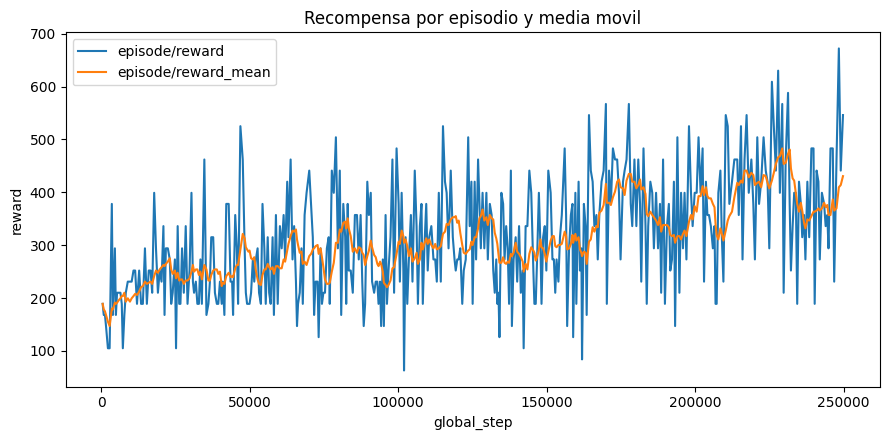

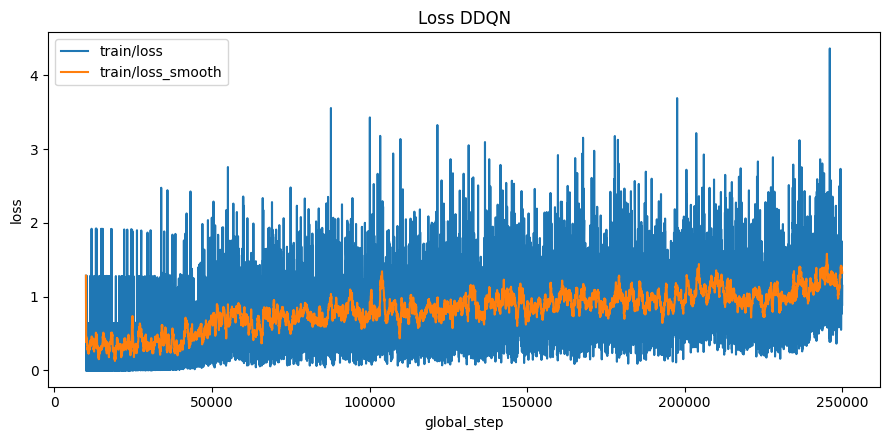

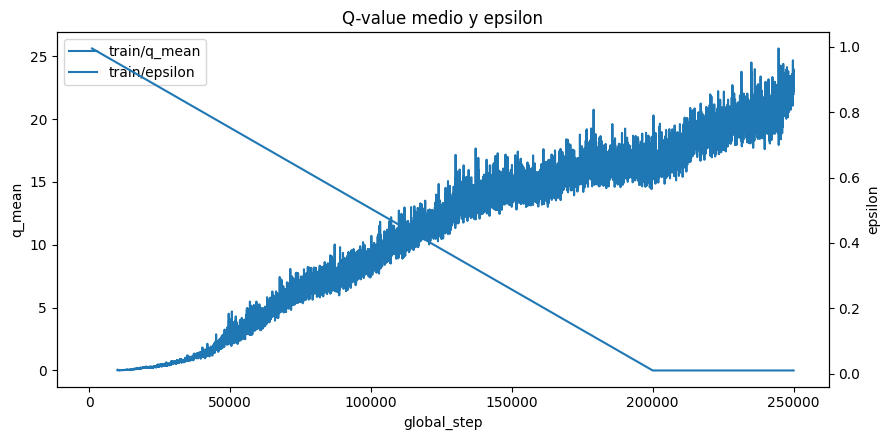

training_figure_count: 3
TENSORBOARD_FIGURES_READY=True


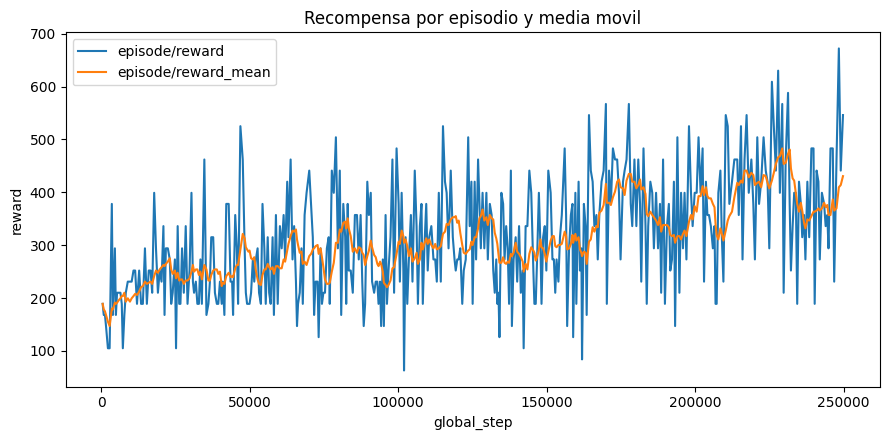

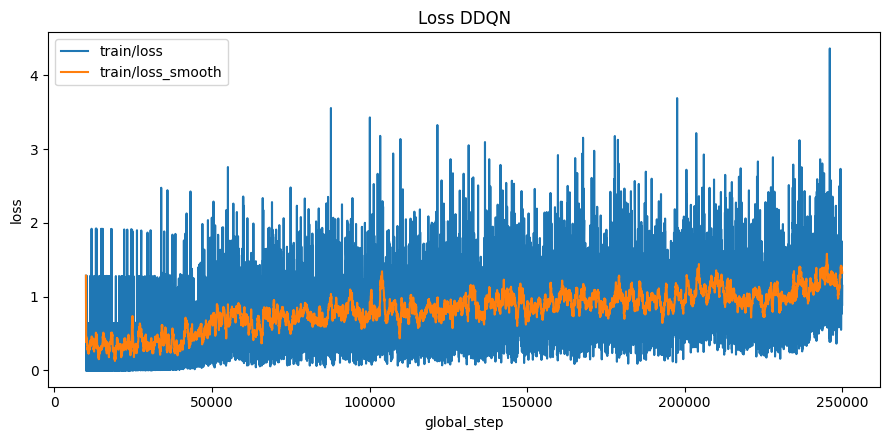

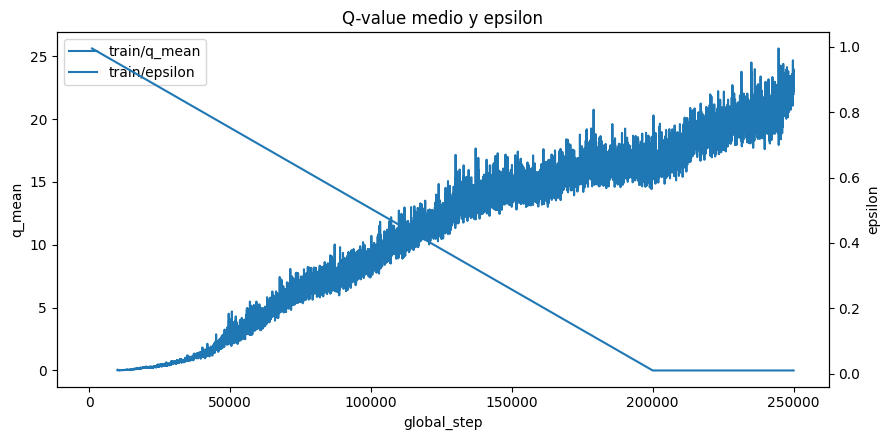

In [8]:
TENSORBOARD_RUN_DIR = Path(os.environ.get("ASSAULT_TENSORBOARD_RUN_DIR") or (Path(os.environ["ASSAULT_TENSORBOARD_DIR"]) / PROJECT_RUN_ID))
training_figures = prepare_training_figures(TENSORBOARD_RUN_DIR, reward_window=10)
rendered_figures = plot_training_figures(training_figures)
for figure in rendered_figures:
    display(figure)
print("training_figure_count:", len(training_figures))
print("TENSORBOARD_FIGURES_READY=True")

## 14. Evaluacion y video desde modelo compacto

**Descripci?n de la celda de c?digo**

Esta celda realiza la evaluaci?n final desde el modelo compacto, compara contra el baseline, genera la figura de explotaci?n, produce el video y muestra el MP4 inline. Primero fija un m?nimo de diez episodios y exige que `EVALUATION_EPSILON` sea exactamente `0.0`, porque la evaluaci?n final debe medir la pol?tica greedy sin exploraci?n. Construye seeds determin?sticas, crea un entorno de evaluaci?n y llama a `evaluate_agent` con el agente cargado desde el artefacto compacto. Despu?s cierra el entorno, imprime el resumen y escribe un JSON at?mico con la evidencia de evaluaci?n, incluyendo modelo, checkpoint fuente, seed base y SHA Git. A continuaci?n genera una figura de rewards por episodio, valida sus datos y compara las m?tricas del agente con el baseline aleatorio. En la segunda mitad define la ruta del MP4, arma metadata del video y llama a `generate_assault_demo_video` con entorno `rgb_array`, seed expl?cita, epsilon cero, m?ximo de pasos y FPS. Si el archivo existe y pesa m?s que cero, imprime datos clave y muestra `Video(..., embed=True)`; si falla el render inline, conserva la ruta para reproducci?n manual.

{'episodes': 10, 'rewards': [504.0, 630.0, 378.0, 273.0, 441.0, 399.0, 609.0, 441.0, 399.0, 399.0], 'mean_reward': 447.3, 'median_reward': 420.0, 'std_reward': 102.47053234954916, 'min_reward': 273.0, 'max_reward': 630.0, 'episode_lengths': [662, 718, 544, 542, 546, 606, 830, 646, 614, 512], 'epsilon': 0.0, 'terminated_episodes': 10, 'truncated_episodes': 0, 'max_steps_per_episode': None, 'episode_seeds': [20042, 20043, 20044, 20045, 20046, 20047, 20048, 20049, 20050, 20051]}
EVALUATION_READY=True


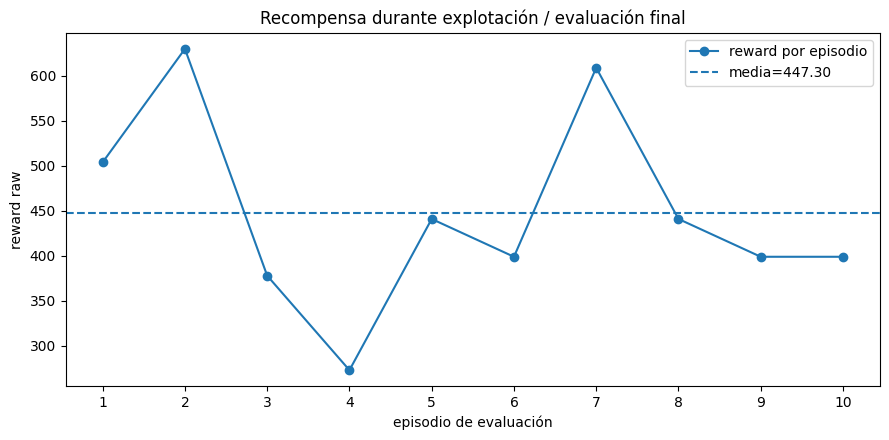

EXPLOITATION_REWARD_FIGURE_PASS= True
BASELINE_COMPARISON= {'agent_mean_reward': 447.3, 'random_mean_reward': 262.5, 'absolute_improvement': 184.8, 'relative_improvement_pct': 70.4, 'agent_beats_random': True}
{'path': '/content/drive/MyDrive/reinforcement_learning_reto_1/videos/assault_ddqn_full_001/assault_ddqn_demo.mp4', 'metadata_path': '/content/drive/MyDrive/reinforcement_learning_reto_1/videos/assault_ddqn_full_001/assault_ddqn_demo.mp4.metadata.json', 'seed': 30042, 'epsilon': 0.0, 'reward': 567.0, 'steps': 774, 'project_run_id': 'assault_ddqn_full_001', 'model_sha256': 'c8cf7ccdfc934009187b45075f131b48a90cddb34f5c6532239c3d63357f66f4', 'fps': 30}
VIDEO_READY=True
video_path= /content/drive/MyDrive/reinforcement_learning_reto_1/videos/assault_ddqn_full_001/assault_ddqn_demo.mp4
video_reward= 567.0
video_steps= 774
video_seed= 30042
video_epsilon= 0.0
video_project_run_id= assault_ddqn_full_001
video_model_sha256= c8cf7ccdfc934009187b45075f131b48a90cddb34f5c6532239c3d63357f66f4


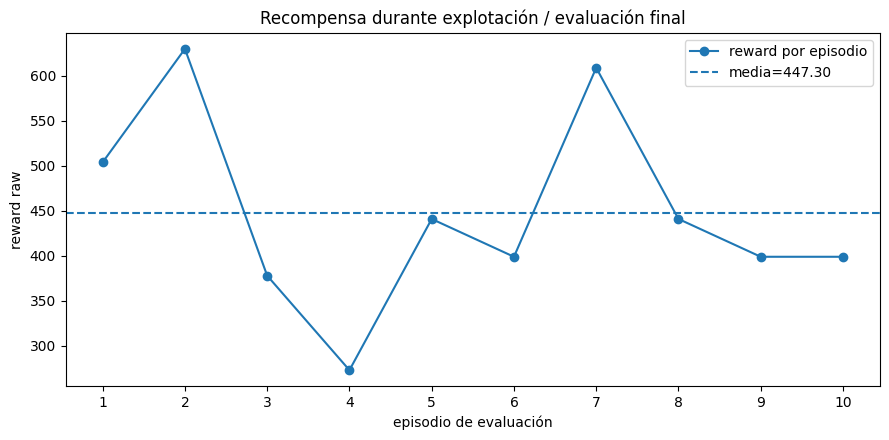

In [9]:
EVALUATION_EPISODES = max(10, int(os.environ.get("ASSAULT_EVALUATION_EPISODES", "10")))
EVALUATION_EPSILON = float(os.environ.get("ASSAULT_EVALUATION_EPSILON", "0.0"))
if EVALUATION_EPSILON != 0.0:
    raise ValueError("HU011 final evaluation requires epsilon=0.0")
FINAL_EVAL_BASE_SEED = int(os.environ.get("ASSAULT_FINAL_EVAL_BASE_SEED", "20042"))
FINAL_EVAL_SEEDS = [FINAL_EVAL_BASE_SEED + index for index in range(EVALUATION_EPISODES)]

eval_env = create_assault_env(config, mode="eval", seed=FINAL_EVAL_SEEDS[0])
try:
    compact_evaluation_summary = evaluate_agent(
        eval_env, compact_agent, episodes=EVALUATION_EPISODES, epsilon=EVALUATION_EPSILON, episode_seeds=FINAL_EVAL_SEEDS,
    )
finally:
    eval_env.close()
print(compact_evaluation_summary.as_dict())
print("EVALUATION_READY=True")

FINAL_EVALUATION_PATH = BASE / "evaluations" / PROJECT_RUN_ID / "final_compact_evaluation.json"
final_evaluation_artifact = build_evaluation_artifact(
    compact_evaluation_summary, compact_model_info, PROJECT_RUN_ID, SOURCE_CHECKPOINT_PATH,
    base_seed=FINAL_EVAL_BASE_SEED, git_sha=bootstrap.resolved_sha,
)
write_json_atomic(FINAL_EVALUATION_PATH, final_evaluation_artifact)

exploitation_figure = plot_exploitation_rewards(compact_evaluation_summary)
display(exploitation_figure)
EXPLOITATION_REWARD_FIGURE_PASS = validate_exploitation_figure_data(compact_evaluation_summary, compact_evaluation_summary.rewards)
print("EXPLOITATION_REWARD_FIGURE_PASS=", EXPLOITATION_REWARD_FIGURE_PASS)

baseline_comparison = compare_with_random_baseline(compact_evaluation_summary, random_baseline)
print("BASELINE_COMPARISON=", baseline_comparison.as_dict())

VIDEO_PATH = Path(os.environ.get("ASSAULT_VIDEO_PATH") or (BASE / "videos" / PROJECT_RUN_ID / "assault_ddqn_demo.mp4"))
video_metadata = {
    "project_run_id": PROJECT_RUN_ID, "source_checkpoint_step": CHECKPOINT_STEP,
    "model_sha256": compact_model_info.sha256, "epsilon": EVALUATION_EPSILON,
    "training_summary": training_summary_for_report,
}
video_summary = generate_assault_demo_video(
    agent=compact_agent,
    env_factory=lambda: create_assault_env(config, mode="eval", seed=seed + 30_000, render_mode="rgb_array"),
    output_path=VIDEO_PATH, metadata=video_metadata, seed=seed + 30_000, epsilon=EVALUATION_EPSILON,
    max_steps=int(os.environ.get("ASSAULT_VIDEO_MAX_STEPS", "1800")), fps=30,
)
print(video_summary.as_dict())
if VIDEO_PATH.exists() and VIDEO_PATH.stat().st_size > 0:
    print("VIDEO_READY=True")
    print("video_path=", VIDEO_PATH)
    print("video_reward=", video_summary.reward)
    print("video_steps=", video_summary.steps)
    print("video_seed=", video_summary.seed)
    print("video_epsilon=", video_summary.epsilon)
    print("video_project_run_id=", video_summary.project_run_id)
    print("video_model_sha256=", video_summary.model_sha256)
    try:
        display(Video(str(VIDEO_PATH), embed=True))
    except Exception as exc:
        print("VIDEO_INLINE_WARNING:", exc)
        print("Video disponible en:", VIDEO_PATH)
else:
    print("VIDEO_READY=False")

## **15. Reporte tecnico academico**

### Problema y objetivo
El objetivo experimental es aprender una política que maximice la recompensa raw y demostrar su desempeño mediante una evaluación independiente de al menos 10 partidas.

## Selección del algoritmo

Para Assault se seleccionó Double Deep Q-Network (DDQN) porque es una buena opción para problemas donde el agente debe elegir entre un conjunto limitado de acciones y aprender a partir de imágenes del juego.

DDQN mejora una de las principales debilidades de DQN: la tendencia a valorar demasiado algunas acciones. Al reducir este problema, el aprendizaje puede ser más estable y las decisiones del agente más confiables.

Frente a las otras alternativas, DQN era una opción válida, pero presenta mayor riesgo de sobreestimar el valor de las acciones. DQN + Prioritized Experience Replay puede aprender más rápido al dar mayor importancia a ciertas experiencias, pero también agrega complejidad al entrenamiento y más parámetros por ajustar. REINFORCE aprende directamente qué acciones tomar, pero suele necesitar más episodios y puede presentar mayor variación durante el entrenamiento, algo poco conveniente en un entorno visual como Assault.

Por estas razones, DDQN ofrecía un buen equilibrio entre estabilidad, simplicidad y capacidad de aprendizaje, manteniendo una complejidad razonable para el desarrollo del agente.



## Condiciones de ejecución del agente

El entrenamiento se configuró buscando un equilibrio entre **estabilidad del aprendizaje, diversidad de experiencias y costo computacional**. Dado que Assault trabaja con observaciones visuales y requiere una red convolucional, la ejecución se realizó sobre GPU y con un perfil de entrenamiento completo de **250.000 timesteps**.

La configuración buscó que el agente primero aprendiera explorando el entorno, luego fuera usando cada vez más lo que ya había aprendido y, al mismo tiempo, evitara cambiar demasiado rápido sus referencias durante el entrenamiento.

### Hiperparámetros de aprendizaje utilizados

Los principales hiperparámetros utilizados fueron:

| Hiperparámetro    |                 Valor | Propósito                                                                        |
| ----------------- | --------------------: | -------------------------------------------------------------------------------- |
| Learning rate     |                `1e-4` | Controlar la magnitud de cada actualización de los pesos                         |
| Gamma             |                `0.99` | Dar alta importancia a recompensas futuras                                       |
| Batch size        |                  `32` | Número de experiencias utilizadas en cada actualización                          |
| Replay Buffer     | `50.000` transiciones | Mantener experiencias diversas y reducir correlación temporal                    |
| Learning starts   |        `10.000` pasos | Acumular experiencia antes de comenzar a entrenar                                |
| Train frequency   |        cada `4` pasos | Regular la frecuencia de actualización de la red                                 |
| Target update     |    cada `1.000` pasos | Mantener estable temporalmente la referencia utilizada para calcular los targets |
| Epsilon inicial   |                 `1.0` | Favorecer exploración al comienzo                                                |
| Epsilon final     |                `0.01` | Mantener una pequeña probabilidad de exploración al final                        |
| Epsilon decay     |       `200.000` pasos | Realizar una transición gradual de exploración a explotación                     |
| Timesteps totales |             `250.000` | Presupuesto total de interacción con el entorno                                  |

Esta configuración permite que el aprendizaje inicialmente sea dominado por la exploración y evolucione progresivamente hacia el aprovechamiento de las acciones que el agente estima como más valiosas.

### Librerías y versiones empleadas

La solución utiliza principalmente **Python, PyTorch, Gymnasium y ALE-Py**. Cada librería cumple una responsabilidad diferente: Gymnasium proporciona la interfaz estándar del entorno, ALE-Py permite ejecutar Assault dentro del Arcade Learning Environment y PyTorch soporta la construcción y optimización de las redes neuronales utilizadas por el agente.

Adicionalmente, se utilizan herramientas de soporte para procesamiento de imágenes, seguimiento de experimentos, visualización de métricas y generación de evidencias de entrenamiento.

#### Librerías, hardware y trazabilidad
| Elemento | Valor |
| --- | --- |
| Python | 3.13.15 |
| Gymnasium | 1.1.1 |
| ALE-Py | 0.10.1 |
| PyTorch | 2.11.0+cu128 |
| CUDA | 12.8 |
| GPU entrenamiento | NVIDIA A100-SXM4-40GB |
| VRAM runtime actual (GB) | 39.49 |
| RAM runtime actual (GB) | 83.47 |
| Git SHA ejecutado | f0a6609be173ba19eb6fe4e41fd61e4524cfd606 |

### Características del hardware utilizado durante el entrenamiento

El entrenamiento completo se realizó en **Google Colab utilizando una GPU NVIDIA A100-SXM4-40GB**.

Este hardware fue adecuado para Assault debido al procesamiento intensivo de imágenes y al uso de una red neuronal convolucional. La GPU permitió ejecutar el entrenamiento de forma eficiente y manejar el volumen de información requerido por el agente durante el aprendizaje.


## Análisis de los resultados obtenidos

Los resultados muestran que el agente fue mejorando su desempeño a medida que avanzó el entrenamiento. Al inicio obtenía recompensas más bajas e inestables, pero con el tiempo empezó a alcanzar valores mayores de forma más frecuente.

Al finalizar, el agente obtuvo una recompensa promedio de **447,3 puntos**, claramente superior al promedio de **262,5 puntos** alcanzado por una política aleatoria. Esto representa una mejora del **70,4%**, lo que indica que el agente aprendió un comportamiento útil para jugar Assault.

### Tiempo de entrenamiento

El entrenamiento completo tomó aproximadamente **10,95 minutos** y permitió completar:

* **250.000 pasos de entrenamiento**
* **417 episodios**
* **60.001 actualizaciones del modelo**

### Puntaje promedio en 10 episodios de evaluación

El agente fue evaluado en **10 partidas independientes**, sin realizar exploración adicional.

| Métrica                   |  Resultado |
| ------------------------- | ---------: |
| Recompensa promedio       | **447,30** |
| Mediana                   |     420,00 |
| Recompensa mínima         |     273,00 |
| Recompensa máxima         |     630,00 |
| Baseline aleatorio        |     262,50 |
| Mejora frente al baseline | **70,40%** |

Los resultados varían entre partidas, pero en promedio el agente se desempeña considerablemente mejor que una política que toma acciones al azar.



### Evolución de la recompensa durante el entrenamiento

La gráfica muestra una tendencia general de mejora. La media de recompensa pasa aproximadamente de **189 puntos al inicio a 430,5 puntos al final**.

Aunque existen subidas y bajadas entre episodios, algo normal en este tipo de juego, cada vez aparecen con mayor frecuencia partidas con recompensas superiores a **400, 500 e incluso 600 puntos**.

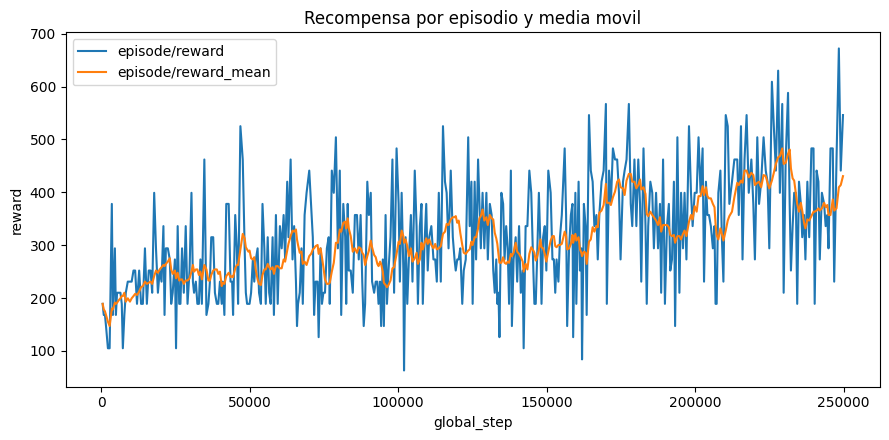


### Evolución durante la explotación

En la evaluación final, las recompensas obtenidas fueron:

`504, 630, 378, 273, 441, 399, 609, 441, 399 y 399`.

Esto muestra que el agente mantiene el aprendizaje cuando juega utilizando únicamente lo aprendido durante el entrenamiento. Los resultados también evidencian que aún existe variación entre partidas, pero el desempeño general se mantiene por encima del comportamiento aleatorio.

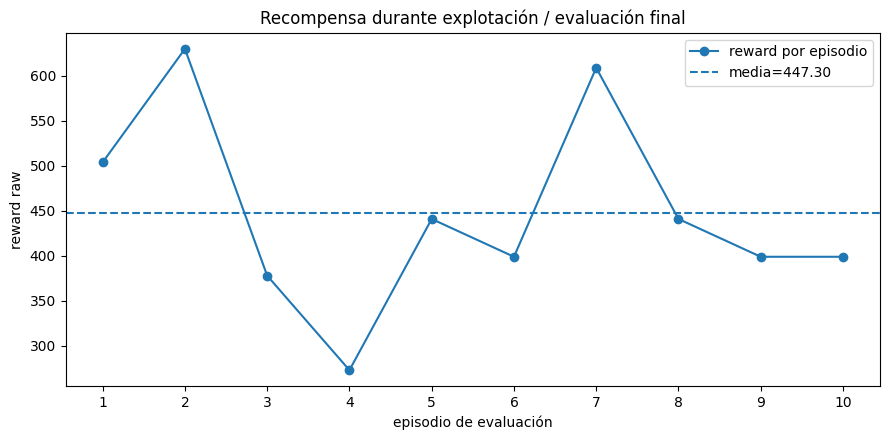


### Comportamiento aprendido por el agente
 
 El agente aprendió a jugar de una forma claramente menos aleatoria, combinando movimientos y disparos para mantenerse activo y conseguir mejores recompensas. Este comportamiento es coherente con el uso de **DDQN**, ya que el algoritmo fue aprendiendo qué acciones resultaban más convenientes en distintas situaciones del juego. Además, la reducción gradual de la exploración, desde un epsilon de **1.0 hasta 0.01**, permitió que al comienzo probara muchas alternativas y, con el tiempo, se apoyara cada vez más en lo aprendido. El uso de **250.000 pasos de entrenamiento** y un factor de descuento de **0.99** también favoreció que el agente aprendiera pensando no solo en la recompensa inmediata, sino en mantener un buen desempeño durante la partida.


### Conclusión general

Los resultados muestran que DDQN fue capaz de aprender un comportamiento útil para jugar Assault, logrando un desempeño claramente superior al de una política aleatoria. El agente obtuvo una recompensa promedio de 447,3 puntos, frente a 262,5 puntos del baseline, lo que representa una mejora del 70,4%.

Esto indica que el método logró aprender qué acciones eran más convenientes en diferentes situaciones del juego y aprovechar ese aprendizaje durante la evaluación. Aunque los resultados todavía presentan variación entre partidas y no permiten afirmar que el agente haya encontrado la mejor estrategia posible, sí demuestran que DDQN es una alternativa efectiva para enfrentar un problema visual y dinámico como Assault.

En general, el experimento evidencia que los métodos de aprendizaje por refuerzo profundo pueden aprender comportamientos útiles directamente a partir de la interacción con el entorno, incluso en escenarios donde las decisiones dependen de información visual y cambian rápidamente.